#Klasifikasi menggunakan SVM

In [ ]:
#setup
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

## Dataset Loading

In [ ]:
#dataset load
df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "zeeshier/weather-forecast-dataset",
    "weather_forecast_data.csv",
)

Using Colab cache for faster access to the 'weather-forecast-dataset' dataset.


## EDA

In [ ]:
#EDA

###PLAN###

#corr matrix
#find most relevant 2 data
#show PCA/whatever of 2 data

#show data (scatter? or maybe corr with yes/no again)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 117.3 KB


In [ ]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


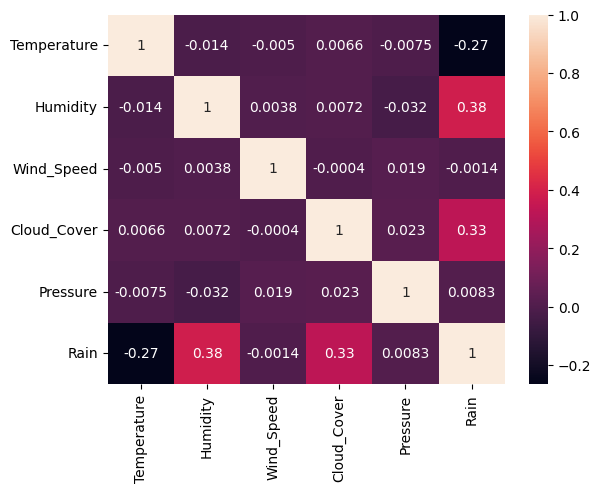

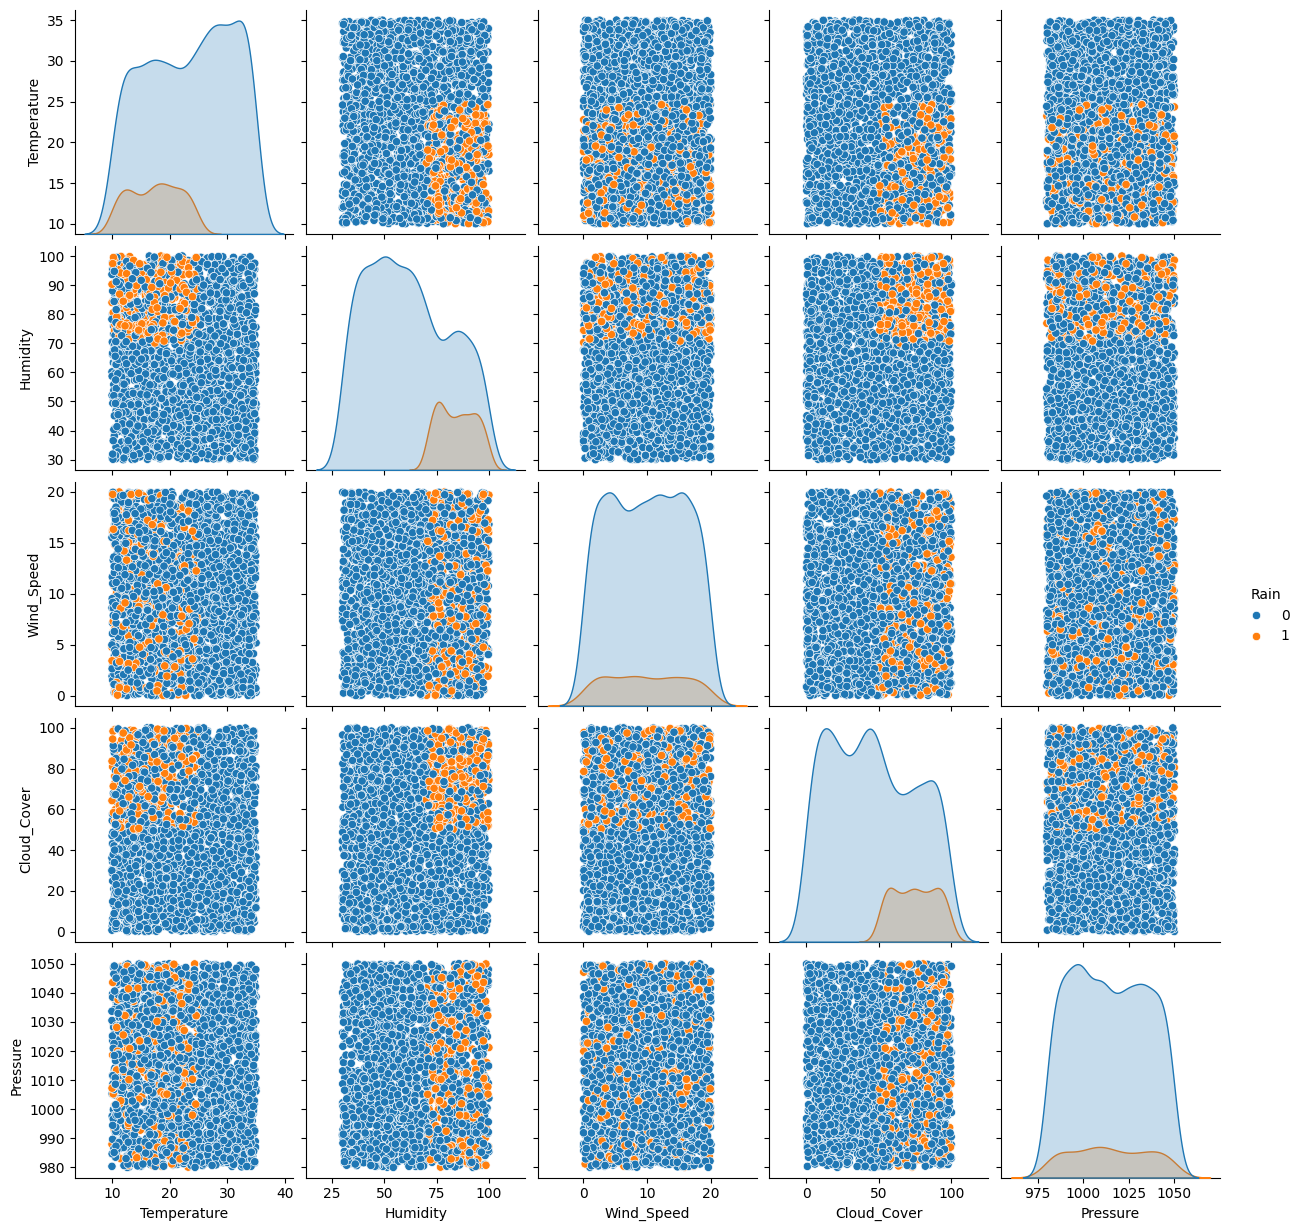

In [ ]:
scalerX = preprocessing.StandardScaler()
encoderY = preprocessing.LabelEncoder()

clean_df = df
clean_df["Rain"] = encoderY.fit_transform(clean_df["Rain"])

sns.heatmap(clean_df.corr(), annot=True)
sns.pairplot(data=clean_df, hue="Rain")

## Feature Selection

In [ ]:
#feature extraction

#take 2 relevant data, delete 2 irrelevant
#data split
#tr,t,v

In [ ]:
clean_df.columns

Index(['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure',
       'Rain'],
      dtype='object')

In [ ]:
clean_df = clean_df.drop(columns=["Wind_Speed","Pressure"])
nums = ["Temperature","Humidity","Cloud_Cover"]
clean_df[nums] = scalerX.fit_transform(clean_df[nums])

X = clean_df.drop(columns="Rain")
y = clean_df[["Rain"]]


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Jumlah data: ",len(X))
print("Jumlah data latih: ",len(x_train))
print("Jumlah data test: ",len(x_test))

Jumlah data:  2500
Jumlah data latih:  2000
Jumlah data test:  500


## Modelling

### Model Training

In [ ]:
model = LinearSVC(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Model Accuracy  :",accuracy_score(y_test, y_pred))
print("Model Precision :",precision_score(y_test, y_pred,average="weighted"))

Model Accuracy  : 0.932
Model Precision : 0.9292404035110704


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.932
Precision: 0.7254901960784313
Recall: 0.6491228070175439
F1-Score: 0.6851851851851852


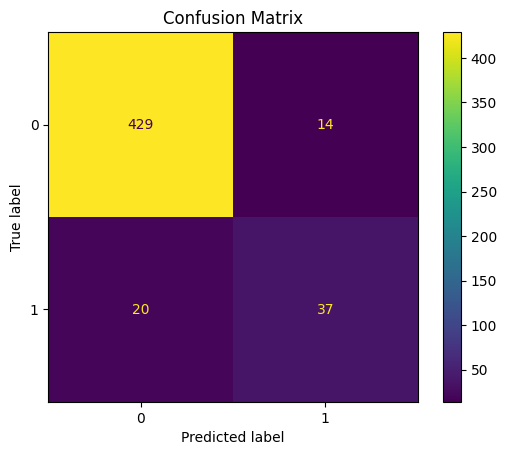

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results = {
        'Confusion Matrix': cm,
        'True Positive (TP)': tp,
        'False Positive (FP)': fp,
        'False Negative (FN)': fn,
        'True Negative (TN)': tn,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    return results

model_eval = evaluate_model(model,x_test,y_test)

print(f"Accuracy: {model_eval["Accuracy"]}")
print(f"Precision: {model_eval["Precision"]}")
print(f"Recall: {model_eval["Recall"]}")
print(f"F1-Score: {model_eval["F1-Score"]}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

### Hyper Parameter Tuning

In [ ]:
#model

#linearSVC

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.2 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV

param_space = {
    'penalty': ['l1','l2'],
    'C': [0.5,1,2,4]
}

bayes_search = BayesSearchCV(estimator=model, search_spaces=param_space, n_iter=32, cv=3, n_jobs=-1, verbose=2, random_state=42)
bayes_search.fit(x_train, y_train)

# Output hasil terbaik
print(f"Best parameters (Bayesian Optimization): {bayes_search.best_params_}")
best_rf_bayes = bayes_search.best_estimator_

# Evaluasi performa model setelah Random Search
y_pred_bayes = best_rf_bayes.predict(x_test)
bayes_mse = mean_squared_error(y_test, y_pred_bayes)
print(f"MSE after Grid Search: {bayes_mse:.2f}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(4), np.str_('l1')] before, using random point [4, 'l2']
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2), np.str_('l2')] before, using random point [0.5, 'l2']
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(0.5), np.str_('l2')] before, using random point [1, 'l1']
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.float64(0.5), np.str_('l1')] before, using random point [0.5, 'l2']
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters (Bayesian Optimization): OrderedDict({'C': 1, 'penalty': 'l2'})
MSE after Grid Search: 0.07


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
#Model baru
new_model = LinearSVC(random_state=42,C=4,penalty='l1')
new_model.fit(x_train, y_train)

new_y_pred = new_model.predict(x_test)

print("Model Accuracy  :",accuracy_score(y_test, new_y_pred))
print("Model Precision :",precision_score(y_test, new_y_pred, average="weighted"))

Model Accuracy  : 0.932
Model Precision : 0.9292404035110704


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy: 0.932
Precision: 0.7254901960784313
Recall: 0.6491228070175439
F1-Score: 0.6851851851851852


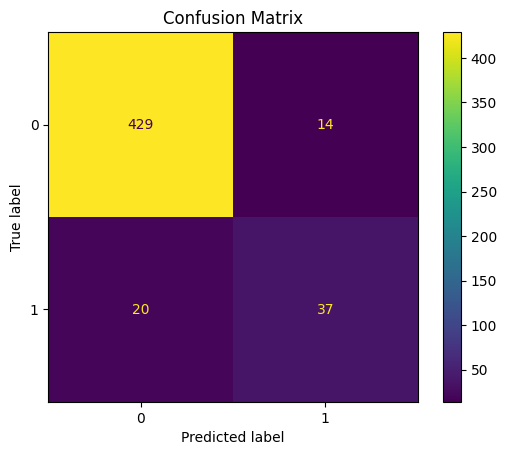

In [ ]:
#evaluasi model

#eval
#accuracy
#loss
#confusion matrix

new_eval = evaluate_model(new_model,x_test,y_test)

print(f"Accuracy: {new_eval["Accuracy"]}")
print(f"Precision: {new_eval["Precision"]}")
print(f"Recall: {new_eval["Recall"]}")
print(f"F1-Score: {new_eval["F1-Score"]}")
ConfusionMatrixDisplay.from_predictions(y_test, new_y_pred)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
#inference
def inference(data):
    new_scaled = scalerX.transform(data)
    new_scaled = pd.DataFrame(
        new_scaled,
        columns=data.columns
    )
    prediction = new_model.predict(new_scaled)
    prediction_label = encoderY.inverse_transform(prediction)
    print(prediction_label)
    return

new_data = pd.DataFrame(
            [[25.5,12.5,26],
            [13,6,25],
            [0,215,115],
            [80,0,0.25]],
            columns=['Temperature', 'Humidity', 'Cloud_Cover']
)

inference(new_data)


['no rain' 'no rain' 'rain' 'no rain']


## SVC PCA Method


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


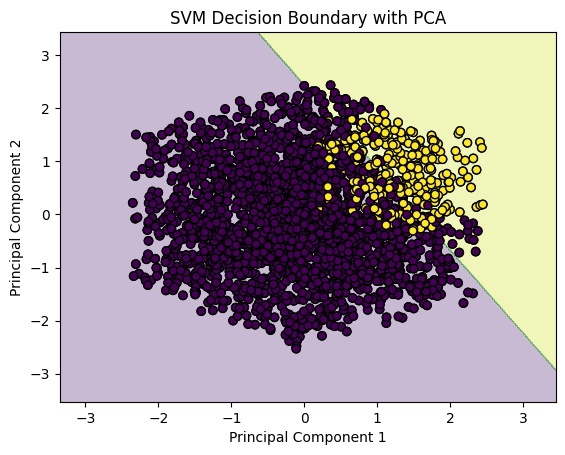

In [ ]:
# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Train LinearSVC
PCA_model = LinearSVC()

PCA_model.fit(X_pca, y)

# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict over grid
Z = PCA_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y["Rain"],
    edgecolors='k'
)

# Plot support vectors
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y["Rain"],
    edgecolors='k'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("SVM Decision Boundary with PCA")

plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)

print(loadings)

     Temperature  Humidity  Cloud_Cover
PC1    -0.696580  0.716349     0.040255
PC2     0.352245  0.292567     0.889004
